<a href="https://colab.research.google.com/github/Ankith-SShetty/PyTorch_tutorial/blob/master/PyTorch_Fundamentals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt


torch.__version__

'2.10.0+cu128'

In [ ]:
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [ ]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test),


(40, 40, 10, 10)

In [ ]:
def plot_prediction(train_data = X_train,
                    train_labels = y_train,
                    test_data = X_test,
                    test_labels = y_test,
                    predictions = None):

  plt.figure(figsize=(10,7))

  plt.scatter(train_data, train_labels, c='b', label = "Training data")
  plt.scatter(test_data, test_labels, c='g', label = 'Tesing data')

  if predictions is not None:
    plt.scatter(test_data, predictions, c='r', label = 'Predictions')

  plt.legend(prop={'size': 14});

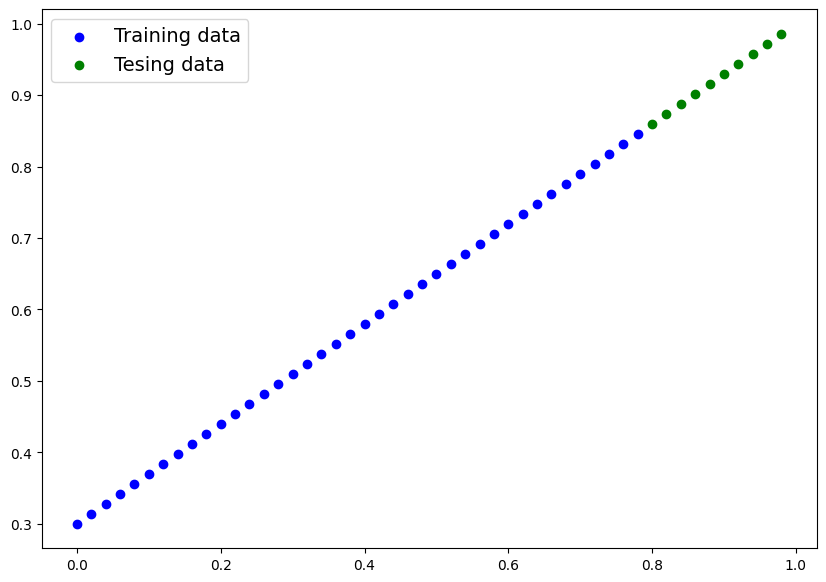

In [ ]:
plot_prediction()

In [ ]:
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1,
                                            dtype=torch.float),
                                requires_grad=True)
    self.bias = nn.Parameter(torch.randn(1,
                                         dtype=torch.float),
                             requires_grad=True)
  def forward(self,x):
    return self.weights * x + self.bias

In [ ]:
torch.manual_seed(42)
model_0 = LinearRegressionModel()
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
with torch.inference_mode():
  y_preds = model_0(X_test)

In [ ]:
print(f"Number of testing samples: {len(X_test)}")
print(f"Number of prediction samples: {len(y_preds)}")
print(f"Prediction value:\n {y_preds}")

Number of testing samples: 10
Number of prediction samples: 10
Prediction value:
 tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


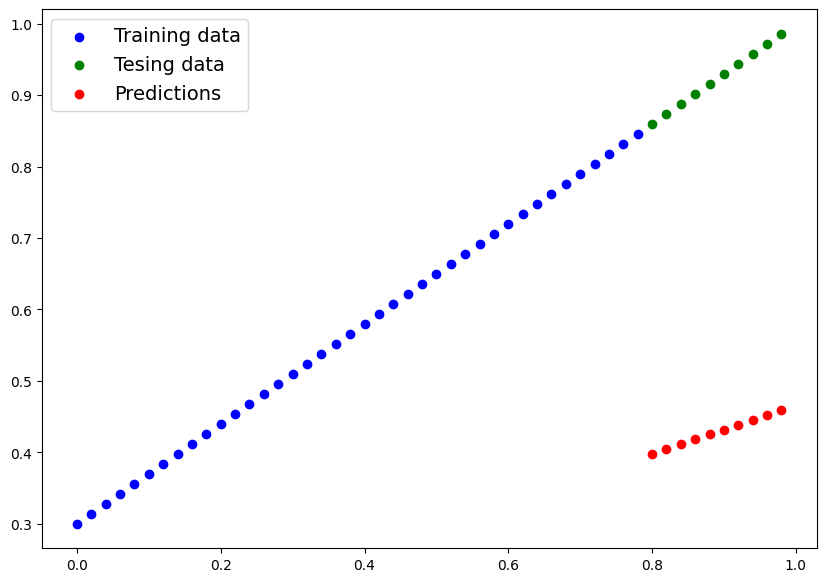

In [ ]:
plot_prediction(predictions=y_preds)

In [ ]:
y_test - y_preds

tensor([[0.4618],
        [0.4691],
        [0.4764],
        [0.4836],
        [0.4909],
        [0.4982],
        [0.5054],
        [0.5127],
        [0.5200],
        [0.5272]])

In [ ]:
loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01)

### Building a training loop and testing loop

0. Loop through the data
1. Forward pass
2. Calculate the loss
3. Optimizer zero grad
4. Loss backward
5. Optimizer step

In [ ]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
torch.manual_seed(42)
# An epcoch is one loop through a data

epoch = 200
epoch_count = []
train_loss_value = []
test_loss_value = []

#0.
for epoch in range(epoch):
  model_0.train()

  # 1. Forward pass
  y_preds = model_0(X_train)

# 2.
  loss = loss_fn(y_preds, y_train)
# 3.
  optimizer.zero_grad()

# 4.
  loss.backward()

# 5.
  optimizer.step()

  model_0.eval() #turns of the different settings which is not required for evaluation


###Testing
  with torch.inference_mode():
    #1. Forward loss
    test_pred = model_0(X_test)

    #2. calculate the loss
    test_loss = loss_fn(test_pred,y_test.type(torch.float))

    if epoch % 10 == 0:
      epoch_count.append(epoch)
      train_loss_value.append(loss.detach().numpy())
      test_loss_value.append(test_loss.detach().numpy())
      print(f"Epoch: {epoch} | MEA Train loss: {loss} | MEA Test loss:{test_loss}")





Epoch: 0 | MEA Train loss: 0.31288138031959534 | MEA Test loss:0.48106518387794495
Epoch: 10 | MEA Train loss: 0.1976713240146637 | MEA Test loss:0.3463551998138428
Epoch: 20 | MEA Train loss: 0.08908725529909134 | MEA Test loss:0.21729660034179688
Epoch: 30 | MEA Train loss: 0.053148526698350906 | MEA Test loss:0.14464017748832703
Epoch: 40 | MEA Train loss: 0.04543796554207802 | MEA Test loss:0.11360953003168106
Epoch: 50 | MEA Train loss: 0.04167863354086876 | MEA Test loss:0.09919948130846024
Epoch: 60 | MEA Train loss: 0.03818932920694351 | MEA Test loss:0.08886633068323135
Epoch: 70 | MEA Train loss: 0.03476089984178543 | MEA Test loss:0.0805937647819519
Epoch: 80 | MEA Train loss: 0.03132382780313492 | MEA Test loss:0.07232122868299484
Epoch: 90 | MEA Train loss: 0.02788739837706089 | MEA Test loss:0.06473556160926819
Epoch: 100 | MEA Train loss: 0.024458957836031914 | MEA Test loss:0.05646304413676262
Epoch: 110 | MEA Train loss: 0.021020207554101944 | MEA Test loss:0.048190496

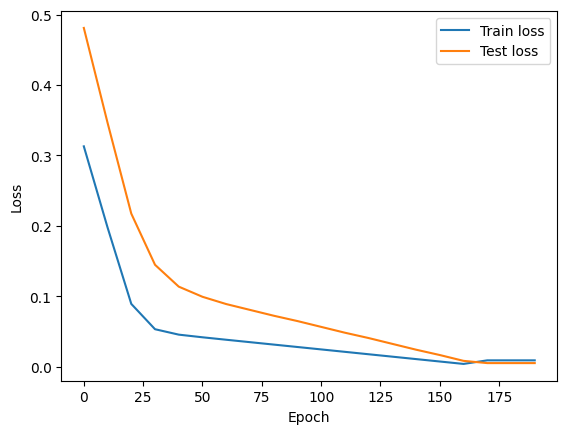

In [ ]:
plt.plot(epoch_count, train_loss_value, label = 'Train loss')
plt.plot(epoch_count, test_loss_value, label = 'Test loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

## Saving a model in PyTorch

There are 3 ways to save and load

1. `torch.save()` - allows you to save a PyTorch object in Python's pickle format

2. `torch.load()` - allows you to save PyTorch object

3. `torch.nn.Module.load_state_dict()` - This allows to load a models save state sictionary

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [ ]:
model_0.eval()

with torch.inference_mode():
  y_preds = model_0(X_test)
y_preds


tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

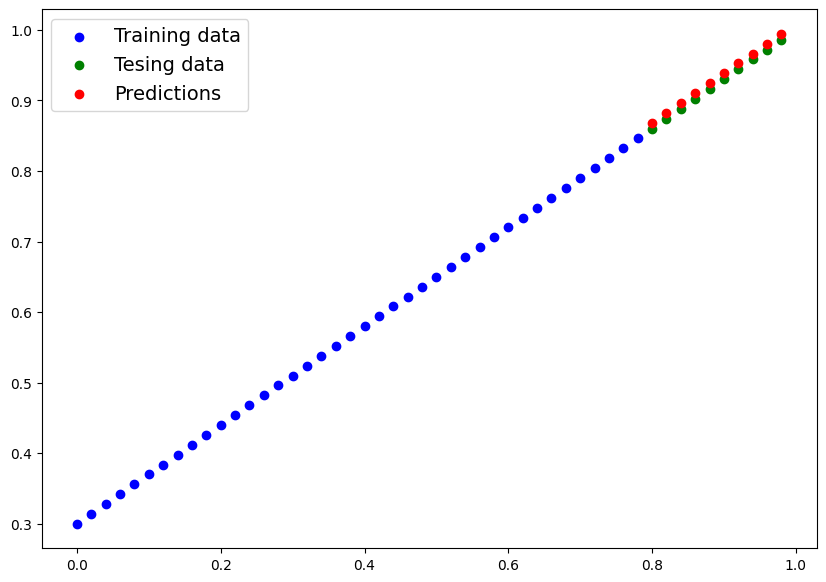

In [ ]:
plot_prediction(predictions=y_preds)

In [ ]:
from pathlib import Path

MODEL_PATH = Path("model")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "01_pytorch_workflow.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME # / operator means "Join paths together"

print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(),
           f=MODEL_SAVE_PATH)


Saving model to: model/01_pytorch_workflow.pth


In [ ]:
!ls -l model/01_pytorch_workflow.pth

-rw-r--r-- 1 root root 1989 Mar  1 12:41 model/01_pytorch_workflow.pth


In [ ]:
loaded_model_0 = LinearRegressionModel()
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

### DATA


In [ ]:
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02

X = torch.arange(start,end,step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [ ]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split],y[:train_split]
X_test, y_test = X[train_split:],y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)


(40, 40, 10, 10)